<a href="https://colab.research.google.com/github/ayeshahabib01/InflammatoryDepressionAnalysis/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Create the 2 subgroups: Inflammatory Depression vs. Non-inflammatory Depression



In [ ]:
import pandas as pd
import numpy as np

# Load the datasets
df_quest = pd.read_csv('questionnaire.csv')
df_labs = pd.read_csv('laboratory.csv')

# Prints the first 20 columns
df_labs.head()

,SEQN,URXUMA,URXUMS,URXUCR,URXCRS,URDACT,WTSSGP2Y,SSAGP,WTSA2YR,URXUAS,...,LBXVMIK,LBXVNB,LBXVOX,LBXVTC,LBXVTE,LBXVTFT,LBXVTHF,LBXVTP,LBXVVB,LBXVXY
0,93703.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,3.2,3.2,24.0,2121.6,13.33,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,93706.0,39.6,39.6,69.0,6099.6,57.39,NaN,NaN,NaN,NaN,...,0.071,0.226,0.017,0.008,0.007,0.028,0.088,0.028,0.032,0.024
4,93707.0,41.6,41.6,209.0,18475.6,19.90,NaN,NaN,24984.393699,5.09,...,0.071,0.226,0.017,0.008,0.007,0.028,0.088,0.028,0.032,0.024


In [ ]:
# 1. Define our target depression columns
dpq_cols = ['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']

# 2. Create a focused dataframe with just the ID and the depression questions
df_dep_clean = df_quest[['SEQN'] + dpq_cols].copy()

# 3. Clean out the 7s and 9s by replacing them with NaN (Not a Number)
for col in dpq_cols:
    df_dep_clean[col] = df_dep_clean[col].replace([7, 9], np.nan)

# 4. Sum across the columns to get the total PHQ-9 score
df_dep_clean['total_phq9'] = df_dep_clean[dpq_cols].sum(axis=1, skipna=True)

# 5. Let's look at a preview
print("Depression scores calculated!")
df_dep_clean[['SEQN', 'total_phq9']].head()

Depression scores calculated!


,SEQN,total_phq9
0,93703.0,0.0
1,93704.0,0.0
2,93705.0,0.0
3,93706.0,0.0
4,93707.0,0.0


In [ ]:
# 1. First, add the 'total_phq9' score directly back into your full questionnaire dataframe
df_quest['total_phq9'] = df_dep_clean['total_phq9']

# 2. Isolate the ID and the primary CRP inflammation column from labs (FIXED HERE)
df_labs_clean = df_labs[['SEQN', 'LBXHSCRP']].copy()
df_labs_clean = df_labs_clean.rename(columns={'LBXHSCRP': 'crp_inflammation'})

# 3. Merge EVERYTHING. This keeps ALL questionnaire columns + adds the CRP column
df_master = pd.merge(df_quest, df_labs_clean, on='SEQN', how='inner')

# 4. Drop rows where CRP or the depression score is missing
df_master = df_master.dropna(subset=['total_phq9', 'crp_inflammation'])

print(f"Master dataframe created! We have {len(df_master)} complete records containing all questionnaire variables and blood markers.")

Master dataframe created! We have 7250 complete records containing all questionnaire variables and blood markers.


In [ ]:
# 1. Create a mask to isolate people with moderate-to-severe depression (PHQ-9 score >= 10)
depressed_mask = df_master['total_phq9'] >= 10

# 2. Group A: Inflammatory Depression (Depressed + High CRP > 3.0)
group_inflammatory = df_master[depressed_mask & (df_master['crp_inflammation'] > 3.0)].copy()

# 3. Group B: Non-Inflammatory Depression (Depressed + Normal CRP <= 3.0)
group_non_inflammatory = df_master[depressed_mask & (df_master['crp_inflammation'] <= 3.0)].copy()

print("Subgrouping complete!")
print(f"Count of Inflammatory Depression Cohort: {len(group_inflammatory)}")
print(f"Count of Non-Inflammatory Depression Cohort: {len(group_non_inflammatory)}")

Subgrouping complete!
Count of Inflammatory Depression Cohort: 199
Count of Non-Inflammatory Depression Cohort: 228


Identifying characteristics for each subgroup:

In [ ]:
import numpy as np

# dictionary of features found in your dataset
variables = {
    'SLQ050': 'Sleep Trouble (1=Yes, 2=No)',
    'SLD012': 'Sleep Duration (Hours on weeknights)',
    'PAQ605': 'Vigorous Activity (1=Yes, 2=No)',
    'SMQ020': 'Smoked 100+ Cigs (1=Yes, 2=No)',
    'ALQ130': 'Avg Alcohol Drinks/Day (Continuous)',
    'HSD010': 'General Health Status (1=Excellent, 5=Poor)',
    'INDFMMPI': 'Income-to-Poverty Ratio (Higher = Wealthier)'
}

for col, description in variables.items():
    if col in df_master.columns:
        # Clean standard NHANES missing/refused data codes (7, 9, 77, 99) where applicable
        if col in ['SLQ050', 'PAQ605', 'SMQ020', 'HSD010']:
            group_inflammatory[col] = group_inflammatory[col].replace([7, 9], np.nan)
            group_non_inflammatory[col] = group_non_inflammatory[col].replace([7, 9], np.nan)
        elif col == 'ALQ130':
            group_inflammatory[col] = group_inflammatory[col].replace([77, 99], np.nan)
            group_non_inflammatory[col] = group_non_inflammatory[col].replace([77, 99], np.nan)

        mean_inf = group_inflammatory[col].mean()
        mean_non_inf = group_non_inflammatory[col].mean()

        print(f"{col} - {description}")
        print(f"  Inflammatory Mean: {mean_inf:.2f}")
        print(f"  Non-Inflammatory Mean: {mean_non_inf:.2f}")
        print(f"  Difference: {abs(mean_inf - mean_non_inf):.2f}\n")
    else:
        print(f"Column '{col}' not found in dataset.\n")

SLQ050 - Sleep Trouble (1=Yes, 2=No)
  Inflammatory Mean: 1.36
  Non-Inflammatory Mean: 1.36
  Difference: 0.00

SLD012 - Sleep Duration (Hours on weeknights)
  Inflammatory Mean: 7.54
  Non-Inflammatory Mean: 7.54
  Difference: 0.00

PAQ605 - Vigorous Activity (1=Yes, 2=No)
  Inflammatory Mean: 1.75
  Non-Inflammatory Mean: 1.71
  Difference: 0.04

SMQ020 - Smoked 100+ Cigs (1=Yes, 2=No)
  Inflammatory Mean: 1.41
  Non-Inflammatory Mean: 1.47
  Difference: 0.07

ALQ130 - Avg Alcohol Drinks/Day (Continuous)
  Inflammatory Mean: 3.10
  Non-Inflammatory Mean: 2.83
  Difference: 0.27

HSD010 - General Health Status (1=Excellent, 5=Poor)
  Inflammatory Mean: 3.69
  Non-Inflammatory Mean: 3.52
  Difference: 0.17

INDFMMPI - Income-to-Poverty Ratio (Higher = Wealthier)
  Inflammatory Mean: 1.74
  Non-Inflammatory Mean: 1.84
  Difference: 0.10



Visualizations

/tmp/ipykernel_32698/4016347625.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Cohort', y='ALQ130', ax=axes[0, 0], palette='Oranges', inner='quartile')
/tmp/ipykernel_32698/4016347625.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Cohort', y='INDFMMPI', ax=axes[0, 1], palette='GnBu')


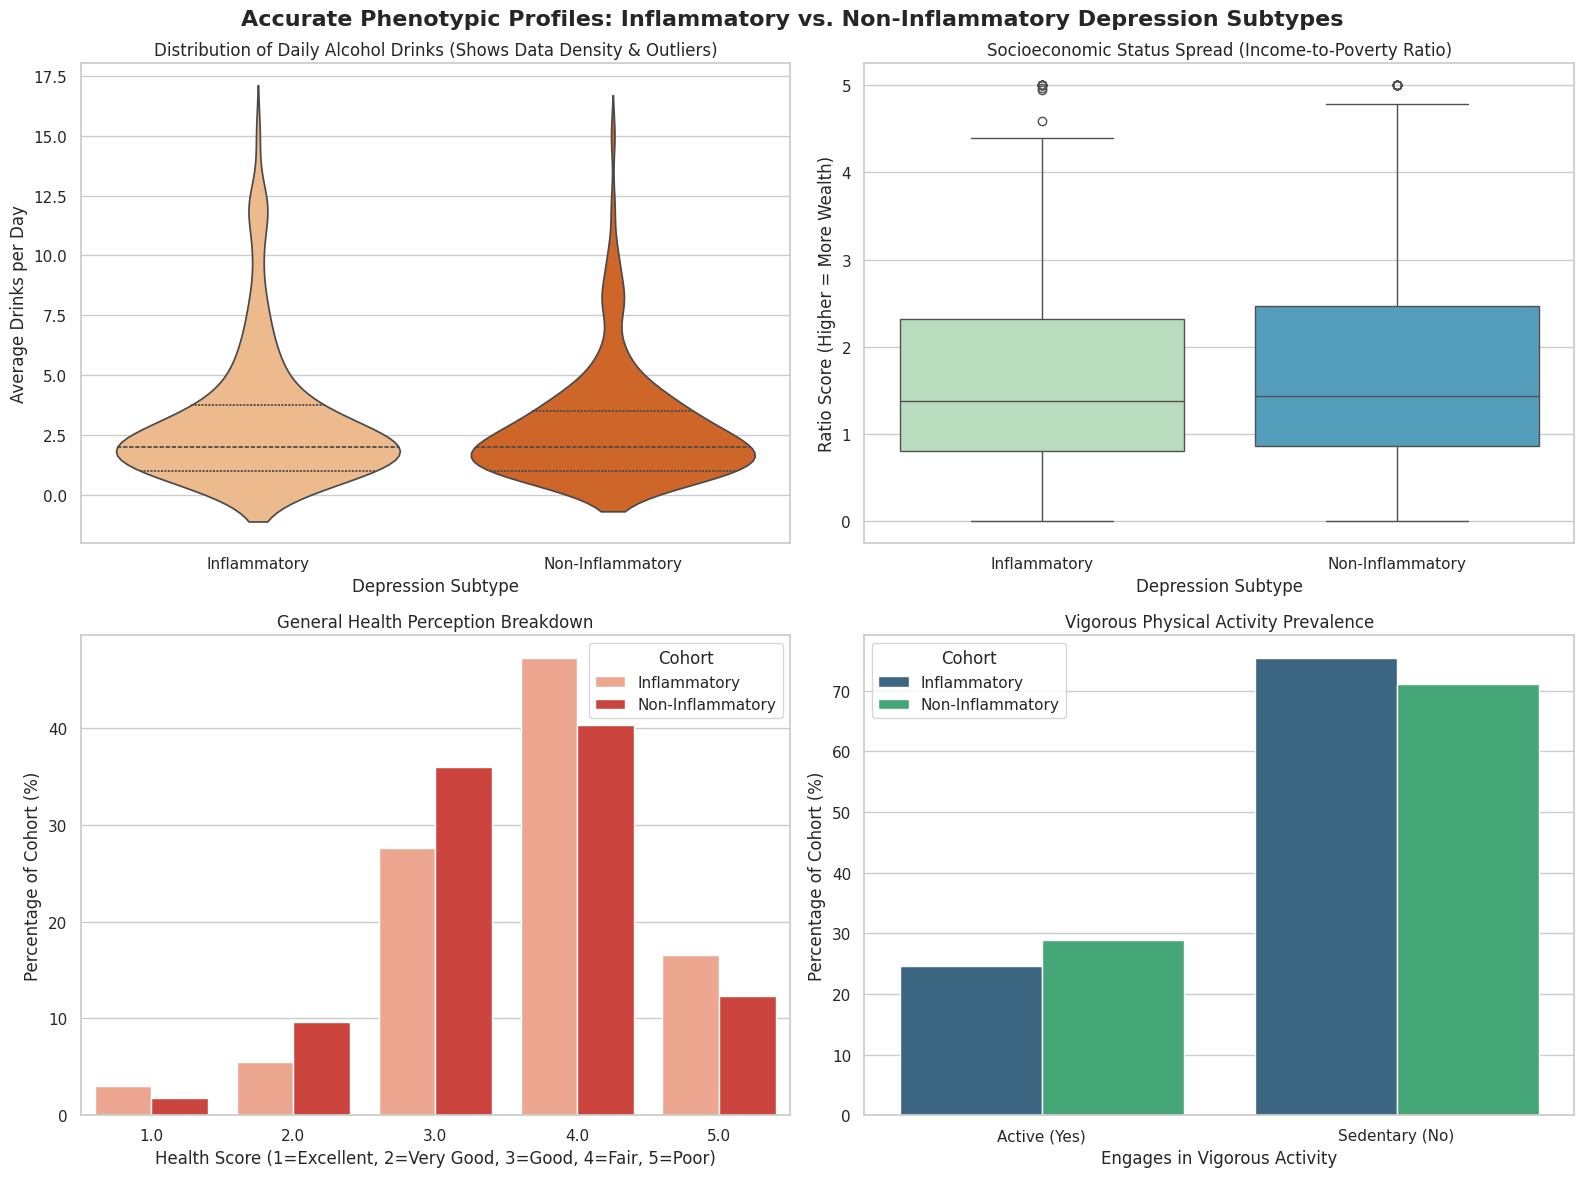

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Combine both cohorts into a single dataframe with a label for Seaborn
group_inflammatory['Cohort'] = 'Inflammatory'
group_non_inflammatory['Cohort'] = 'Non-Inflammatory'
df_plot = pd.concat([group_inflammatory, group_non_inflammatory], axis=0)

# 2. Set up a 2x2 grid for distribution visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PLOT 1: Violin Plot for Alcohol Consumption (Shows full density, medians, and skewness)
sns.violinplot(data=df_plot, x='Cohort', y='ALQ130', ax=axes[0, 0], palette='Oranges', inner='quartile')
axes[0, 0].set_title('Distribution of Daily Alcohol Drinks (Shows Data Density & Outliers)')
axes[0, 0].set_ylabel('Average Drinks per Day')
axes[0, 0].set_xlabel('Depression Subtype')

# PLOT 2: Box Plot for Income-to-Poverty Ratio (Shows true median and IQR spread)
sns.boxplot(data=df_plot, x='Cohort', y='INDFMMPI', ax=axes[0, 1], palette='GnBu')
axes[0, 1].set_title('Socioeconomic Status Spread (Income-to-Poverty Ratio)')
axes[0, 1].set_ylabel('Ratio Score (Higher = More Wealth)')
axes[0, 1].set_xlabel('Depression Subtype')

# PLOT 3: Percentage Distribution for General Health Status (1-5 Ordinal Scale)
health_counts = df_plot.groupby(['Cohort', 'HSD010']).size().reset_index(name='count')
cohort_totals = df_plot.groupby('Cohort').size().reset_index(name='total')
health_pct = pd.merge(health_counts, cohort_totals, on='Cohort')
health_pct['Percentage'] = (health_pct['count'] / health_pct['total']) * 100

sns.barplot(data=health_pct, x='HSD010', y='Percentage', hue='Cohort', ax=axes[1, 0], palette='Reds')
axes[1, 0].set_title('General Health Perception Breakdown')
axes[1, 0].set_xlabel('Health Score (1=Excellent, 2=Very Good, 3=Good, 4=Fair, 5=Poor)')
axes[1, 0].set_ylabel('Percentage of Cohort (%)')

# PLOT 4: Percentage Breakdown of Vigorous Activity (True Binary Split)
activity_counts = df_plot.groupby(['Cohort', 'PAQ605']).size().reset_index(name='count')
activity_pct = pd.merge(activity_counts, cohort_totals, on='Cohort')
activity_pct['Percentage'] = (activity_pct['count'] / activity_pct['total']) * 100
activity_pct['Activity Status'] = activity_pct['PAQ605'].map({1.0: 'Active (Yes)', 2.0: 'Sedentary (No)'})

sns.barplot(data=activity_pct.dropna(subset=['Activity Status']), x='Activity Status', y='Percentage', hue='Cohort', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Vigorous Physical Activity Prevalence')
axes[1, 1].set_xlabel('Engages in Vigorous Activity')
axes[1, 1].set_ylabel('Percentage of Cohort (%)')

plt.suptitle('Accurate Phenotypic Profiles: Inflammatory vs. Non-Inflammatory Depression Subtypes', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()